In [1]:
from rdkit import Chem
from chembl_webresource_client.new_client import new_client
import pandas as pd

print("RDKit + ChEMBL working ✅")

RDKit + ChEMBL working ✅


In [6]:
import pandas as pd
df= pd.read_csv('bioactivity_preprocessed_data.csv')

In [7]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [8]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

In [9]:
df_lipinski = lipinski(df.canonical_smiles)

In [10]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,285.365,1.91460,2.0,4.0
1,285.365,1.91460,2.0,4.0
2,285.365,1.91460,2.0,4.0
3,291.413,2.18820,2.0,4.0
4,335.425,3.06780,2.0,4.0
...,...,...,...,...
686,430.533,4.55132,2.0,5.0
687,405.504,3.88302,2.0,5.0
688,407.520,4.65362,2.0,5.0
689,403.467,2.55502,2.0,5.0


In [11]:
df

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,CHEMBL1788203,CCCC[C@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,42.0
1,CHEMBL263501,CCCCC(CC(=O)NO)S(=O)(=O)c1ccccc1,active,12.0
2,CHEMBL2092878,CCCC[C@@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,9.0
3,CHEMBL77258,CCCCC(CC(=O)NO)S(=O)(=O)C1CCCCC1,active,14.0
4,CHEMBL78001,CCCCC(CC(=O)NO)S(=O)(=O)c1ccc2ccccc2c1,active,13.0
...,...,...,...,...
686,CHEMBL5742512,CCC1(c2cnccc2Sc2ccc(/C=C/c3ccnc(C)c3)cc2)NC(=O...,active,1.0
687,CHEMBL5800908,Cc1cc(C#Cc2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,1.0
688,CHEMBL6006240,Cc1cc(/C=C/c2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,1.0
689,CHEMBL5761540,Cc1cc(C#Cc2ccc(Sc3cnn(C)c3C3NC(=O)NC3=O)cc2)ccn1,active,1.0


In [12]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [13]:
df_combined

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1788203,CCCC[C@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,42.0,285.365,1.91460,2.0,4.0
1,CHEMBL263501,CCCCC(CC(=O)NO)S(=O)(=O)c1ccccc1,active,12.0,285.365,1.91460,2.0,4.0
2,CHEMBL2092878,CCCC[C@@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,9.0,285.365,1.91460,2.0,4.0
3,CHEMBL77258,CCCCC(CC(=O)NO)S(=O)(=O)C1CCCCC1,active,14.0,291.413,2.18820,2.0,4.0
4,CHEMBL78001,CCCCC(CC(=O)NO)S(=O)(=O)c1ccc2ccccc2c1,active,13.0,335.425,3.06780,2.0,4.0
...,...,...,...,...,...,...,...,...
686,CHEMBL5742512,CCC1(c2cnccc2Sc2ccc(/C=C/c3ccnc(C)c3)cc2)NC(=O...,active,1.0,430.533,4.55132,2.0,5.0
687,CHEMBL5800908,Cc1cc(C#Cc2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,1.0,405.504,3.88302,2.0,5.0
688,CHEMBL6006240,Cc1cc(/C=C/c2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,1.0,407.520,4.65362,2.0,5.0
689,CHEMBL5761540,Cc1cc(C#Cc2ccc(Sc3cnn(C)c3C3NC(=O)NC3=O)cc2)ccn1,active,1.0,403.467,2.55502,2.0,5.0


In [34]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm')
        
    return x

In [35]:
df_combined.standard_value.describe()

count    6.910000e+02
mean     3.468855e+04
std      2.141474e+05
min      8.500000e-02
25%      1.925000e+01
50%      4.000000e+02
75%      1.000000e+04
max      5.000000e+06
Name: standard_value, dtype: float64

In [36]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [37]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [39]:
def norm_value(df):
    df = df.copy()
    norm = []
    
    for i in df['standard_value']:
        if float(i) > 100000000:
            norm.append(100000000)
        else:
            norm.append(i)
    
    df['standard_value_norm'] = norm
    
    if 'standard_value' in df.columns:
        df = df.drop(columns=['standard_value'])
    
    return df

In [40]:
df_combined.columns

Index(['molecule_chembl_id', 'canonical_smiles', 'bioactivity_class',
       'standard_value', 'MW', 'LogP', 'NumHDonors', 'NumHAcceptors',
       'standard_value_norm'],
      dtype='object')

In [41]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL1788203,CCCC[C@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,42.0
1,CHEMBL263501,CCCCC(CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,12.0
2,CHEMBL2092878,CCCC[C@@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,9.0
3,CHEMBL77258,CCCCC(CC(=O)NO)S(=O)(=O)C1CCCCC1,active,291.413,2.18820,2.0,4.0,14.0
4,CHEMBL78001,CCCCC(CC(=O)NO)S(=O)(=O)c1ccc2ccccc2c1,active,335.425,3.06780,2.0,4.0,13.0
...,...,...,...,...,...,...,...,...
686,CHEMBL5742512,CCC1(c2cnccc2Sc2ccc(/C=C/c3ccnc(C)c3)cc2)NC(=O...,active,430.533,4.55132,2.0,5.0,1.0
687,CHEMBL5800908,Cc1cc(C#Cc2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,405.504,3.88302,2.0,5.0,1.0
688,CHEMBL6006240,Cc1cc(/C=C/c2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,407.520,4.65362,2.0,5.0,1.0
689,CHEMBL5761540,Cc1cc(C#Cc2ccc(Sc3cnn(C)c3C3NC(=O)NC3=O)cc2)ccn1,active,403.467,2.55502,2.0,5.0,1.0


In [42]:
df_norm.standard_value_norm.describe()

count    6.910000e+02
mean     3.468855e+04
std      2.141474e+05
min      8.500000e-02
25%      1.925000e+01
50%      4.000000e+02
75%      1.000000e+04
max      5.000000e+06
Name: standard_value_norm, dtype: float64

In [46]:
import numpy as np

def pIC50(df):
    df = df.copy()
    
    pIC50_vals = []
    
    for i in df['standard_value_norm']:
        if i <= 0:
            pIC50_vals.append(None)
        else:
            molar = i * 1e-9
            pIC50_vals.append(-np.log10(molar))
    
    df['pIC50'] = pIC50_vals
    
    # ✅ SAFE DROP (won’t crash)
    if 'standard_value_norm' in df.columns:
        df = df.drop(columns=['standard_value_norm'])
    
    return df

In [47]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL1788203,CCCC[C@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,7.376751
1,CHEMBL263501,CCCCC(CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,7.920819
2,CHEMBL2092878,CCCC[C@@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,8.045757
3,CHEMBL77258,CCCCC(CC(=O)NO)S(=O)(=O)C1CCCCC1,active,291.413,2.18820,2.0,4.0,7.853872
4,CHEMBL78001,CCCCC(CC(=O)NO)S(=O)(=O)c1ccc2ccccc2c1,active,335.425,3.06780,2.0,4.0,7.886057
...,...,...,...,...,...,...,...,...
686,CHEMBL5742512,CCC1(c2cnccc2Sc2ccc(/C=C/c3ccnc(C)c3)cc2)NC(=O...,active,430.533,4.55132,2.0,5.0,9.000000
687,CHEMBL5800908,Cc1cc(C#Cc2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,405.504,3.88302,2.0,5.0,9.000000
688,CHEMBL6006240,Cc1cc(/C=C/c2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,407.520,4.65362,2.0,5.0,9.000000
689,CHEMBL5761540,Cc1cc(C#Cc2ccc(Sc3cnn(C)c3C3NC(=O)NC3=O)cc2)ccn1,active,403.467,2.55502,2.0,5.0,9.000000


In [48]:
df_final.pIC50.describe()

count    691.000000
mean       6.341639
std        1.658656
min        2.301030
25%        5.000000
50%        6.397940
75%        7.715606
max       10.070581
Name: pIC50, dtype: float64

In [49]:
df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL1788203,CCCC[C@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,7.376751
1,CHEMBL263501,CCCCC(CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,7.920819
2,CHEMBL2092878,CCCC[C@@H](CC(=O)NO)S(=O)(=O)c1ccccc1,active,285.365,1.91460,2.0,4.0,8.045757
3,CHEMBL77258,CCCCC(CC(=O)NO)S(=O)(=O)C1CCCCC1,active,291.413,2.18820,2.0,4.0,7.853872
4,CHEMBL78001,CCCCC(CC(=O)NO)S(=O)(=O)c1ccc2ccccc2c1,active,335.425,3.06780,2.0,4.0,7.886057
...,...,...,...,...,...,...,...,...
686,CHEMBL5742512,CCC1(c2cnccc2Sc2ccc(/C=C/c3ccnc(C)c3)cc2)NC(=O...,active,430.533,4.55132,2.0,5.0,9.000000
687,CHEMBL5800908,Cc1cc(C#Cc2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,405.504,3.88302,2.0,5.0,9.000000
688,CHEMBL6006240,Cc1cc(/C=C/c2ccc(Sc3ccsc3C3NC(=O)NC3=O)cc2)ccn1,active,407.520,4.65362,2.0,5.0,9.000000
689,CHEMBL5761540,Cc1cc(C#Cc2ccc(Sc3cnn(C)c3C3NC(=O)NC3=O)cc2)ccn1,active,403.467,2.55502,2.0,5.0,9.000000


In [51]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

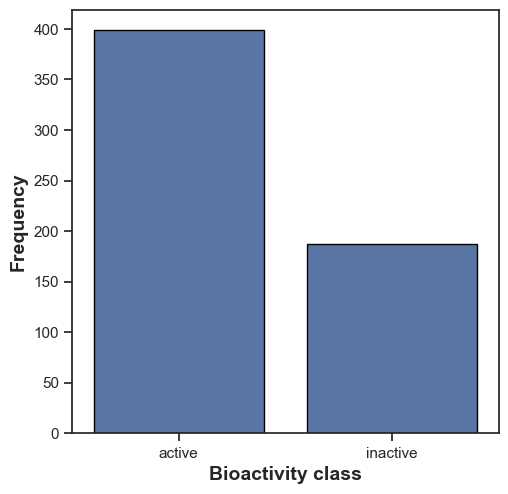

In [52]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

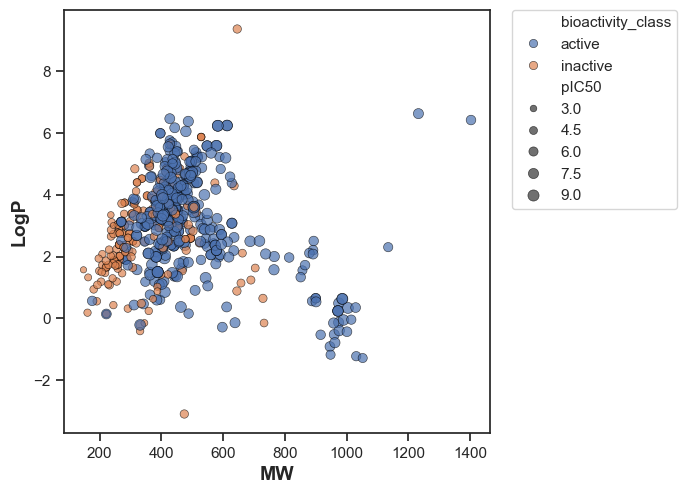

In [53]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

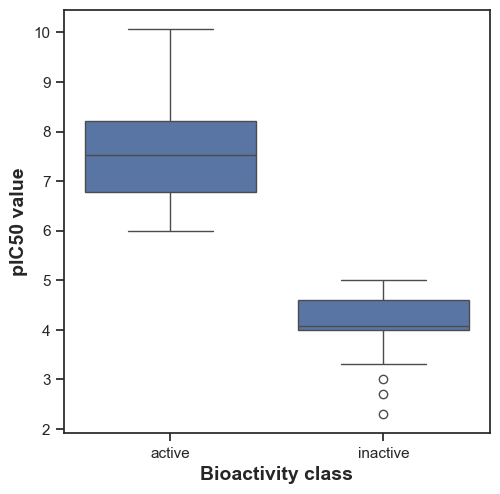

In [54]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

In [55]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [56]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,74613.0,5.998606e-85,0.05,Different distribution (reject H0)


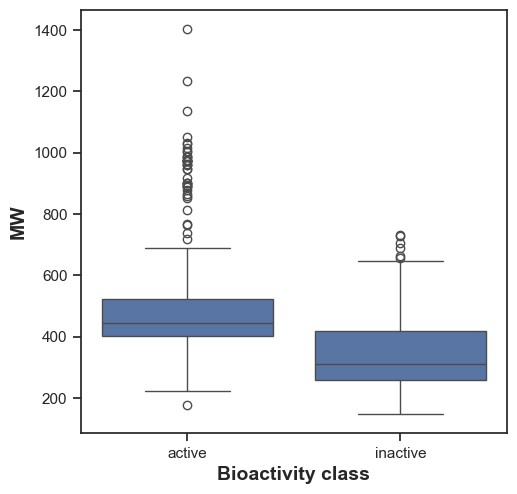

In [57]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [58]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,59798.5,5.382123e-32,0.05,Different distribution (reject H0)


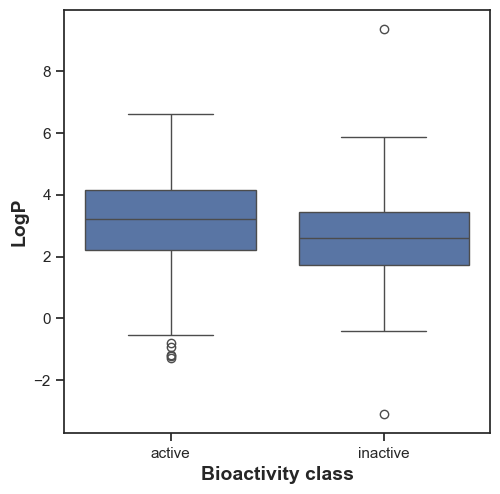

In [59]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

In [60]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,45414.5,0.000022,0.05,Different distribution (reject H0)


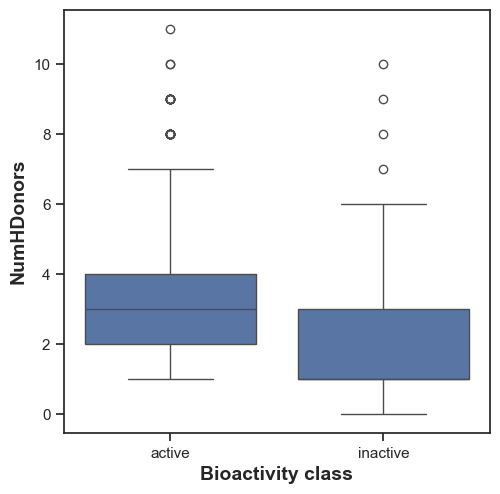

In [61]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

In [62]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,54054.0,2.088645e-19,0.05,Different distribution (reject H0)


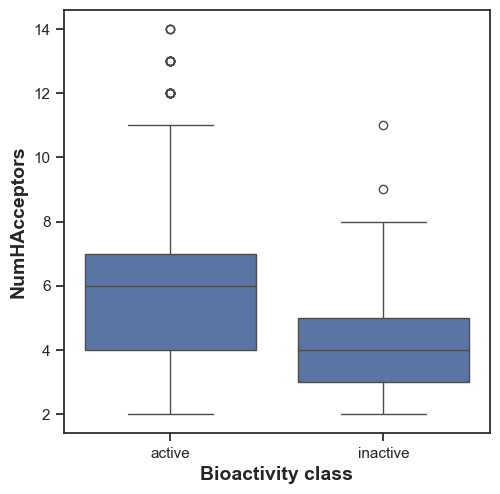

In [63]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [64]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,56170.5,1.186784e-23,0.05,Different distribution (reject H0)


In [66]:
import zipfile
import os

with zipfile.ZipFile('results.zip', 'w') as z:
    for file in os.listdir():
        if file.endswith('.csv') or file.endswith('.pdf'):
            z.write(file)

print("Zipped successfully ✅")

Zipped successfully ✅


In [67]:
#save df_2class to csv
df_2class.to_csv('bioactivity_data_3class_pIC50.csv')